<a href="https://colab.research.google.com/github/Droc-sid/Switch_Hybrid_Recommender_System/blob/main/Switch_Hybrid_Recommender_Version_1_0_0_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Switch Hybridization Recommendation System
**SCT213-C002-0025/2022 | Mike Masyuki Sammy | JKUAT**

Optimizing Product Recommendation Systems for Higher Conversion Rates  
in E-Commerce Using Switch Hybridization




## Cell 1 — Run this cell first. It installs everything the notebook needs. Runtime will restart automatically after pip installs.


In [ ]:
!pip install kagglehub scikit-surprise scikit-learn pandas numpy matplotlib seaborn tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 49.8 MB/s eta 0:00:00


In [ ]:
import os
import warnings
import datetime as dt
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split as surprise_split, cross_validate
from tqdm import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## Cell 3 — Authenticate and download the Online Retail dataset.


In [ ]:
# place the file at ~/.kaggle/kaggle.json manually.

import kagglehub

path = kagglehub.dataset_download("ulrikthygepedersen/online-retail-dataset")
print("📂 Dataset downloaded to:", path)

csv_path = os.path.join(path, 'online_retail.csv')
raw_data = pd.read_csv(csv_path, encoding='ISO-8859-1')

print(f"\nRaw dataset shape: {raw_data.shape}")
print(raw_data.head())


# ============================================================
# CELL 4 — Data Cleaning Pipeline
# (Reproduced exactly from your EDA notebook — no changes)
# ============================================================

def create_description_map(df, count_dups=False):
    X = df.copy()
    desc_counts = X.groupby(['StockCode', 'Description']).size().reset_index(name='count')
    best = desc_counts.sort_values(['StockCode', 'count'], ascending=[True, False])
    best = best.drop_duplicates('StockCode')
    return dict(zip(best['StockCode'], best['Description'])), best

def clean_datatypes(df):
    X = df.copy()
    X['InvoiceDate'] = pd.to_datetime(X['InvoiceDate'], errors='coerce')
    X['CustomerID']  = X['CustomerID'].fillna(0).astype(int)
    X['InvoiceNo']   = X['InvoiceNo'].astype(str)
    X['StockCode']   = X['StockCode'].astype(str)
    return X

def clean_txt_cols(df):
    X = df.copy()
    X['Description'] = X['Description'].str.strip()
    X['Country']     = X['Country'].str.strip()
    X['StockCode']   = X['StockCode'].str.strip()
    X['InvoiceNo']   = X['InvoiceNo'].str.strip()
    X['Description'] = X['Description'].str.upper()
    non_gift         = X[~X['StockCode'].str.contains('gift', case=False, na=False)]
    X.loc[non_gift.index, 'StockCode'] = non_gift['StockCode'].str.upper()
    X['Country']     = X['Country'].replace('EIRE', 'Ireland')
    X['StockCode']   = X['StockCode'].replace('22016', 'gift_0001_100')
    return X

def clean_descriptions(df):
    X = df.copy()
    desc_map, _ = create_description_map(X)
    X['Description'] = X['StockCode'].map(desc_map)
    return X

def isolate_non_product_entries(df, export_data=False):
    X = df.copy()
    c_prefix      = X['InvoiceNo'].str.startswith('C', na=False)
    damages       = X.loc[(X['Quantity'] < 0) & (~c_prefix) & (~X['Description'].isnull())]
    zero_price    = X.loc[X['UnitPrice'] == 0]
    op_codes      = ['POST', 'BANK CHARGES', 'DOT', 'AMAZONFEE']
    operating_df  = X.loc[X['StockCode'].isin(op_codes)]
    samples       = X.loc[X['StockCode'] == 'S'].index.tolist()
    donations     = X.loc[X['StockCode'] == 'CRUK'].index.tolist()
    gift_vouchers = X.loc[X['StockCode'].str.contains('gift', na=False)].index.tolist()
    rows_to_drop  = set(
        X[X['StockCode'] == 'B'].index.tolist() +
        zero_price.index.tolist() +
        operating_df.index.tolist() +
        damages.index.tolist() +
        samples + gift_vouchers + donations
    )
    return X.drop(rows_to_drop)

def impute_missing_customers(df):
    X = df.copy()
    X['CustomerID'] = X['CustomerID'].astype(str).replace('0', 'Guest')
    return X

def clean_pipeline(df):
    X = df.copy()
    X = clean_datatypes(X)
    X = clean_txt_cols(X)
    X = clean_descriptions(X)
    X = isolate_non_product_entries(X)
    X = impute_missing_customers(X)
    return X

cleaned_df = clean_pipeline(raw_data)
print(f"✅ Cleaning done. Remaining records: {cleaned_df.shape[0]:,}")


# ============================================================
# CELL 5 — Feature Engineering
# (Reproduced exactly from your EDA notebook)
# ============================================================

def create_temporal_features(df):
    X = df.copy()
    X['Month_Year'] = X['InvoiceDate'].dt.strftime('%m/%y')
    X['DayOfWeek']  = X['InvoiceDate'].dt.day_name()
    X['Hour']       = X['InvoiceDate'].dt.hour
    X['Revenue']    = (X['UnitPrice'] * X['Quantity']).round(2)
    return X

def create_cust_profiles(df):
    most_recent = df['InvoiceDate'].max() + dt.timedelta(days=1)
    cdf = df.groupby('CustomerID').agg(
        Recency        = ('InvoiceDate', lambda x: (most_recent - x.max()).days),
        Frequency      = ('InvoiceNo',   'nunique'),
        Monetary       = ('Revenue',     lambda x: x[x > 0].sum()),
        Net_Revenue    = ('Revenue',     'sum'),
        Refunds        = ('Revenue',     lambda x: abs(x[x < 0].sum())),
        Tenure_Days    = ('InvoiceDate', lambda x: (x.max() - x.min()).days),
        Avg_Basket_Size= ('Quantity',    lambda x: (x.sum() / df.loc[x.index, 'InvoiceNo'].nunique()).round(2)),
        Country        = ('Country',     lambda x: x.mode()[0])
    ).reset_index()
    cdf['Return_Money_Rate'] = (cdf['Refunds'] / (cdf['Monetary'] + 0.01) * 100).round(2)
    return cdf

def create_invoice_summary(df):
    idf = df.groupby('InvoiceNo').agg(
        CustomerID       = ('CustomerID',  lambda x: x.mode()[0]),
        InvoiceDate      = ('InvoiceDate', 'first'),
        TotalUnits       = ('Quantity',    'sum'),
        Variety          = ('StockCode',   'nunique'),
        InvoiceRevenue   = ('Revenue',     'sum'),
        Country          = ('Country',     'first'),
        Month_Year       = ('Month_Year',  lambda x: x.mode()[0]),
        Transaction_Type = ('Quantity',    lambda x: 'Refund' if (x < 0).any() else 'Gross Sales')
    ).reset_index()
    return idf

temporal_df  = create_temporal_features(cleaned_df)
customer_df  = create_cust_profiles(temporal_df)
invoice_df   = create_invoice_summary(temporal_df)

print(f"✅ Feature engineering complete.")
print(f"   temporal_df : {temporal_df.shape}")
print(f"   customer_df : {customer_df.shape}")
print(f"   invoice_df  : {invoice_df.shape}")
print("\nCustomer profiles sample:")
print(customer_df.head())




100%|██████████| 7.38M/7.38M [00:00<00:00, 9.74MB/s]

Extracting files...


📂 Dataset downloaded to: /root/.cache/kagglehub/datasets/ulrikthygepedersen/online-retail-dataset/versions/2

Raw dataset shape: (541909, 8)
  InvoiceNo StockCode                          Description  Quantity          InvoiceDate  UnitPrice  CustomerID  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6  2010-12-01 08:26:00       2.55     17850.0   
1    536365     71053                  WHITE METAL LANTERN         6  2010-12-01 08:26:00       3.39     17850.0   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8  2010-12-01 08:26:00       2.75     17850.0   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6  2010-12-01 08:26:00       3.39     17850.0   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6  2010-12-01 08:26:00       3.39     17850.0   

          Country  
0  United Kingdom  
1  United Kingdom  
2  United Kingdom  
3  United Kingdom  
4  United Kingdom  
✅ Cleaning done. Remaining records: 537,25

## Cell 6 — Interaction matrix
Builds the (CustomerID × StockCode) matrix using implicit purchase frequency. Clips wholesale outliers at the 99th percentile, then log-scales — standard practice for implicit feedback datasets.


In [ ]:
# implicit rating. The signal used is purchase frequency
# (how many times a customer bought a given product).
# Guest transactions are excluded from CF — no persistent
# identity means no useful collaborative signal.

print("Building user-item interaction matrix...")

# Drop Guest users for CF modelling
cf_df = temporal_df[
    (temporal_df['CustomerID'] != 'Guest') &
    (temporal_df['Quantity'] > 0)            # gross sales only
].copy()

# Implicit rating = total units purchased per (customer, product)
interaction_df = (
    cf_df.groupby(['CustomerID', 'StockCode'])['Quantity']
    .sum()
    .reset_index()
    .rename(columns={'Quantity': 'ImplicitRating'})
)

# Clip extreme quantities to reduce the influence of wholesale orders
upper = interaction_df['ImplicitRating'].quantile(0.99)
interaction_df['ImplicitRating'] = interaction_df['ImplicitRating'].clip(1, upper)

# Log-scale to compress the range (common for implicit feedback)
interaction_df['ImplicitRating'] = np.log1p(interaction_df['ImplicitRating']).round(4)

print(f"  Interaction records : {len(interaction_df):,}")
print(f"  Unique customers    : {interaction_df['CustomerID'].nunique():,}")
print(f"  Unique products     : {interaction_df['StockCode'].nunique():,}")

# Sparsity check
n_users    = interaction_df['CustomerID'].nunique()
n_products = interaction_df['StockCode'].nunique()
sparsity   = 1 - (len(interaction_df) / (n_users * n_products))
print(f"  Matrix sparsity     : {sparsity * 100:.2f}%")

print("\nSample interactions:")
print(interaction_df.head(10))




Building user-item interaction matrix...
  Interaction records : 266,450
  Unique customers    : 4,337
  Unique products     : 3,662
  Matrix sparsity     : 98.32%

Sample interactions:
  CustomerID StockCode  ImplicitRating
0      12346     23166          5.3033
1      12347     16008          3.2189
2      12347     17021          3.6109
3      12347     20665          1.9459
4      12347     20719          3.7136
5      12347     20780          2.5649
6      12347     20782          1.9459
7      12347     20966          2.3979
8      12347     21035          1.9459
9      12347     21041          2.5649


## Cell 7 — Content feature matrix
TF-IDF (500 features, unigrams + bigrams) over product descriptions, plus average unit price and total units sold per product. Pre-computes the full cosine similarity matrix — feasible at ~4k products.


In [ ]:
# compute cosine similarity between items.

print("Building product content feature matrix (TF-IDF)...")

# One description per StockCode
product_meta = (
    temporal_df[['StockCode', 'Description', 'UnitPrice']]
    .dropna(subset=['Description'])
    .drop_duplicates('StockCode')
    .copy()
)

# Average unit price per product (used as a feature signal)
avg_price = (
    temporal_df.groupby('StockCode')['UnitPrice']
    .mean()
    .reset_index()
    .rename(columns={'UnitPrice': 'AvgPrice'})
)
product_meta = product_meta.merge(avg_price, on='StockCode', how='left')

# Purchase popularity (number of times each product was bought)
popularity = (
    temporal_df[temporal_df['Quantity'] > 0]
    .groupby('StockCode')['Quantity']
    .sum()
    .reset_index()
    .rename(columns={'Quantity': 'TotalSold'})
)
product_meta = product_meta.merge(popularity, on='StockCode', how='left')
product_meta['TotalSold'] = product_meta['TotalSold'].fillna(0)

# TF-IDF on product descriptions
tfidf = TfidfVectorizer(
    max_features=500,
    stop_words='english',
    ngram_range=(1, 2),   # unigrams + bigrams catch colour/style modifiers
    min_df=2
)
tfidf_matrix = tfidf.fit_transform(product_meta['Description'])

print(f"  Products in content matrix : {product_meta.shape[0]:,}")
print(f"  TF-IDF feature dimensions  : {tfidf_matrix.shape[1]}")

# Pre-compute full cosine similarity matrix — kept sparse in memory
# For large catalogs you would use approximate nearest-neighbors (FAISS),
# but the ~4k product size here fits comfortably in RAM.
cos_sim_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Index for quick product lookup
product_meta = product_meta.reset_index(drop=True)
product_idx  = pd.Series(product_meta.index, index=product_meta['StockCode'])

print("✅ Content feature matrix built.")




Building product content feature matrix (TF-IDF)...
  Products in content matrix : 3,815
  TF-IDF feature dimensions  : 500
✅ Content feature matrix built.


## Cell 8 — CF model (SVD)
Trains SVD matrix factorization (Surprise library) with n_factors=50, L2 regularisation. Equivalent to ALS. Reports RMSE and MAE against a 20% holdout.


In [ ]:
# which implements an equivalent of ALS under the hood.
# The interaction_df log-scaled implicit ratings are used.

print("Training Collaborative Filtering model (SVD)...")

reader = Reader(rating_scale=(
    interaction_df['ImplicitRating'].min(),
    interaction_df['ImplicitRating'].max()
))

surprise_data = Dataset.load_from_df(
    interaction_df[['CustomerID', 'StockCode', 'ImplicitRating']],
    reader
)

# Hold out 20% for offline evaluation
trainset, testset = surprise_split(surprise_data, test_size=0.20, random_state=42)

# SVD hyperparameters informed by literature (Koren et al., 2009)
cf_model = SVD(
    n_factors  = 50,     # latent factor dimensions
    n_epochs   = 30,
    lr_all     = 0.005,  # learning rate
    reg_all    = 0.02,   # L2 regularisation
    random_state = 42
)
cf_model.fit(trainset)

cf_predictions = cf_model.test(testset)
cf_rmse = accuracy.rmse(cf_predictions, verbose=False)
cf_mae  = accuracy.mae(cf_predictions, verbose=False)

print(f"  CF Model (SVD) — RMSE : {cf_rmse:.4f}  |  MAE : {cf_mae:.4f}")
print("✅ CF model trained.")




Training Collaborative Filtering model (SVD)...
  CF Model (SVD) — RMSE : 0.6268  |  MAE : 0.4686
✅ CF model trained.


## Cell 9 — The key step
switching features for 2,000 sampled customers, the notebook evaluates both models on a last-invoice holdout and computes 12 features per user: interaction count, log-interaction, frequency, recency, tenure, monetary value, basket size, return rate, and both models' confidence scores. Each sample is labelled 0 (CF won) or 1 (CBF won).


In [ ]:
def cbf_recommend(purchased_stock_codes, top_k=10, user_history_items=None):
    """
    Content-based recommendations for a user.
    purchased_stock_codes : list of StockCodes the user has bought
    top_k                 : number of recommendations to return
    user_history_items    : (Optional) List of items to consider as 'seen' and exclude.
                            Used for evaluation to define 'seen' items before a holdout.
    Returns a DataFrame with columns [StockCode, Description, cbf_score]
    """
    # Use user_history_items if provided, otherwise use purchased_stock_codes as the basis for 'known' items
    known_items_for_cbf = user_history_items if user_history_items is not None else purchased_stock_codes

    known = [sc for sc in known_items_for_cbf if sc in product_idx]
    if not known:
        # Fall back to global popularity if no content signal
        return (
            product_meta.sort_values('TotalSold', ascending=False)
            .head(top_k)[['StockCode', 'Description', 'AvgPrice', 'TotalSold']]
            .assign(cbf_score=0.0)
        )

    idxs       = [product_idx[sc] for sc in known]
    sim_scores = cos_sim_matrix[idxs].mean(axis=0)  # average over purchased items

    # Build score series indexed by product position
    scores_series = pd.Series(sim_scores, index=product_meta.index)

    # Exclude already-purchased items (based on user_history_items for evaluation, or purchased_stock_codes otherwise)
    exclude_set = set(known_items_for_cbf)
    scores_series = scores_series.drop(index=[product_idx[sc] for sc in exclude_set if sc in product_idx], errors='ignore')

    top_indices = scores_series.nlargest(top_k).index
    result = product_meta.loc[top_indices, ['StockCode', 'Description', 'AvgPrice', 'TotalSold']].copy()
    result['cbf_score'] = scores_series.loc[top_indices].values
    return result.reset_index(drop=True)


def cf_recommend(customer_id, top_k=10, user_history_items=None):
    """
    Collaborative filtering recommendations for a returning user.
    customer_id         : string CustomerID
    top_k               : number of recommendations to return
    user_history_items  : (Optional) List of items to consider as 'seen' and exclude.
                          Used for evaluation to define 'seen' items before a holdout.
    Returns a DataFrame with columns [StockCode, Description, cf_score]
    """
    # Products the user has already interacted with. Use user_history_items if provided.
    if user_history_items is not None:
        seen = set(user_history_items)
    else:
        seen = set(
            interaction_df.loc[interaction_df['CustomerID'] == customer_id, 'StockCode']
        )

    all_products = product_meta['StockCode'].tolist()
    unseen       = [p for p in all_products if p not in seen]

    predictions  = [(p, cf_model.predict(customer_id, p).est) for p in unseen]
    predictions.sort(key=lambda x: x[1], reverse=True)

    top_products = [p for p, _ in predictions[:top_k]]
    scores       = [s for _, s in predictions[:top_k]]

    result = product_meta[product_meta['StockCode'].isin(top_products)].copy()
    score_map = dict(zip(top_products, scores))
    result['cf_score'] = result['StockCode'].map(score_map)
    result = result.sort_values('cf_score', ascending=False)
    return result[['StockCode', 'Description', 'AvgPrice', 'TotalSold', 'cf_score']].reset_index(drop=True)


print("✅ CF and CBF recommendation functions defined.")

✅ CF and CBF recommendation functions defined.


## Cell 10 — This is the key step for ML-based switching. For every customer in the validation set we compute features


In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler here

print("Building switching feature dataset for meta-classifier training...")

# We need customers who appear in the interaction matrix
cf_customers = interaction_df['CustomerID'].unique().tolist()

# --- Evaluate per-user RMSE for CF and CBF on held-out interactions ---
# Strategy: for each customer sample, hold out their last invoice
# and measure which model predicted those items more accurately.

# Build a per-customer last-invoice holdout
temporal_cf = temporal_df[
    (temporal_df['CustomerID'] != 'Guest') &
    (temporal_df['Quantity'] > 0)
].copy()

temporal_cf = temporal_cf.sort_values(['CustomerID', 'InvoiceDate'])

# Last invoice per customer
last_invoice = (
    temporal_cf.groupby('CustomerID')['InvoiceNo']
    .last()
    .reset_index()
    .rename(columns={'InvoiceNo': 'LastInvoice'})
)

# Sample up to 2000 customers for tractable computation
sample_customers = last_invoice['CustomerID'].sample(
    min(2000, len(last_invoice)), random_state=42
).tolist()

rows = []
print("  Computing per-user model performance (this may take ~2 minutes)...")

for cid in tqdm(sample_customers):
    last_inv = last_invoice.loc[last_invoice['CustomerID'] == cid, 'LastInvoice'].values[0]

    # Items purchased in last invoice — these are our "ground truth" for holdout evaluation
    holdout_items = temporal_cf[
        (temporal_cf['CustomerID'] == cid) &
        (temporal_cf['InvoiceNo']  == last_inv)
    ]['StockCode'].tolist()

    if not holdout_items:
        continue

    # History = all purchases BEFORE the last invoice
    history_items = temporal_cf[
        (temporal_cf['CustomerID'] == cid) &
        (temporal_cf['InvoiceNo']  != last_inv)
    ]['StockCode'].tolist()

    history_count = len(set(history_items))

    # ---- CF score: average predicted rating for holdout items ----
    cf_scores_list = [cf_model.predict(cid, item).est for item in holdout_items]
    cf_pred_mean   = np.mean(cf_scores_list)

    # ---- CBF score: average cosine similarity for holdout items given history ----
    if history_items:
        known_history = [sc for sc in history_items if sc in product_idx]
        if known_history:
            h_idxs     = [product_idx[sc] for sc in known_history]
            user_vec   = cos_sim_matrix[h_idxs].mean(axis=0)
            ho_idxs    = [product_idx[sc] for sc in holdout_items if sc in product_idx]
            cbf_sim    = float(np.mean(user_vec[ho_idxs])) if ho_idxs else 0.0
        else:
            cbf_sim = 0.0
    else:
        cbf_sim = 0.0

    # ---- Switching Features ----
    cust_profile = customer_df[customer_df['CustomerID'] == cid]
    if cust_profile.empty:
        continue

    cp = cust_profile.iloc[0]

    rows.append({
        # Identity
        'CustomerID'        : cid,
        # Switching features (per Procedure Step 3)
        'interaction_count' : history_count,
        'log_interaction'   : np.log1p(history_count),
        'frequency'         : float(cp['Frequency']),
        'recency'           : float(cp['Recency']),
        'tenure_days'       : float(cp['Tenure_Days']),
        'monetary'          : float(cp['Monetary']),
        'avg_basket_size'   : float(cp['Avg_Basket_Size']),
        'return_money_rate' : float(cp['Return_Money_Rate']),
        'holdout_size'      : len(holdout_items),
        # Model confidence signals (raw values)
        'cf_pred_mean'      : cf_pred_mean,
        'cbf_sim_mean'      : cbf_sim,
    })

switch_features_df = pd.DataFrame(rows)

# Scale cf_pred_mean and cbf_sim_mean for a fair comparison in 'better_model'
min_max_scaler = MinMaxScaler()
# Applying scaler directly to the relevant columns
switch_features_df[['cf_pred_mean_scaled', 'cbf_sim_mean_scaled']] = \
    min_max_scaler.fit_transform(switch_features_df[['cf_pred_mean', 'cbf_sim_mean']])

# Re-calculate 'cf_minus_cbf' using the scaled values as well, for consistency
switch_features_df['cf_minus_cbf_scaled'] = switch_features_df['cf_pred_mean_scaled'] - switch_features_df['cbf_sim_mean_scaled']

# Target: which model performed better on holdout (using scaled scores)?
# CF wins when its *scaled* predicted score >= *scaled* CBF similarity score
switch_features_df['better_model'] = np.where(
    switch_features_df['cf_pred_mean_scaled'] >= switch_features_df['cbf_sim_mean_scaled'],
    0, # CF wins
    1  # CBF wins
)

print(f"\n  Switching feature rows built : {len(switch_features_df):,}")
print(f"  CF better  (label=0)         : {(switch_features_df['better_model']==0).sum()}")
print(f"  CBF better (label=1)         : {(switch_features_df['better_model']==1).sum()}")
print(switch_features_df.head())

Building switching feature dataset for meta-classifier training...
  Computing per-user model performance (this may take ~2 minutes)...


100%|██████████| 2000/2000 [04:57<00:00,  6.73it/s]


  Switching feature rows built : 2,000
  CF better  (label=0)         : 1953
  CBF better (label=1)         : 47
  CustomerID  interaction_count  log_interaction  frequency  recency  tenure_days  monetary  avg_basket_size  \
0      17786                 24         3.218876        2.0     85.0        231.0    278.74           100.00   
1      14320                 23         3.178054        3.0    207.0        126.0    477.79            79.67   
2      15978                  0         0.000000        1.0     77.0          0.0   1098.78           888.00   
3      12364                 46         3.850148        4.0      8.0        104.0   1208.10           374.75   
4      14566                  0         0.000000        1.0    111.0          0.0   1432.00           800.00   

   return_money_rate  holdout_size  cf_pred_mean  cbf_sim_mean  cf_pred_mean_scaled  cbf_sim_mean_scaled  \
0               0.00            44      1.238276      0.047930             0.118254             0.047930 

## Cell 11 — Meta-classifier (ML-based router)
Logistic Regression with class_weight='balanced' trained on those switching features. Reports accuracy, F1, ROC-AUC, 5-fold cross-validation, and feature importance coefficients. This is the ML-based switching favoured over the hard threshold.


In [ ]:
# switching features. This is the ML-based routing approach
# favoured over the hard threshold rule.
# Features → model selection (0 = CF, 1 = CBF)

print("Training ML switching meta-classifier (Logistic Regression)...")

FEATURE_COLS = [
    'interaction_count',
    'log_interaction',
    'frequency',
    'recency',
    'tenure_days',
    'monetary',
    'avg_basket_size',
    'return_money_rate',
    'holdout_size',
    # Use scaled versions of confidence scores
    'cf_pred_mean_scaled',
    'cbf_sim_mean_scaled',
    'cf_minus_cbf_scaled', # This will now be difference of scaled values
]

X_sw = switch_features_df[FEATURE_COLS].values
y_sw = switch_features_df['better_model'].values

X_train_sw, X_test_sw, y_train_sw, y_test_sw = train_test_split(
    X_sw, y_sw, test_size=0.25, stratify=y_sw, random_state=42
)

# Scale features — critical for LR convergence
scaler = StandardScaler()
X_train_sw_sc = scaler.fit_transform(X_train_sw)
X_test_sw_sc  = scaler.transform(X_test_sw)

# Logistic Regression with L2 regularisation
meta_clf = LogisticRegression(
    C           = 1.0,
    max_iter    = 500,
    class_weight= 'balanced',    # handles class imbalance
    random_state= 42
)
meta_clf.fit(X_train_sw_sc, y_train_sw)

y_pred_sw  = meta_clf.predict(X_test_sw_sc)
y_prob_sw  = meta_clf.predict_proba(X_test_sw_sc)[:, 1]

sw_accuracy  = (y_pred_sw == y_test_sw).mean()
sw_precision = precision_score(y_test_sw, y_pred_sw, zero_division=0)
sw_recall    = recall_score(y_test_sw, y_pred_sw, zero_division=0)
sw_f1        = f1_score(y_test_sw, y_pred_sw, zero_division=0)
sw_auc       = roc_auc_score(y_test_sw, y_prob_sw)

print(f"\n  Meta-Classifier Performance on Held-Out Set:")
print(f"  Accuracy   : {sw_accuracy:.4f}")
print(f"  Precision  : {sw_precision:.4f}")
print(f"  Recall     : {sw_recall:.4f}")
print(f"  F1 Score   : {sw_f1:.4f}")
print(f"  ROC-AUC    : {sw_auc:.4f}")
print()
print(classification_report(y_test_sw, y_pred_sw, target_names=['CF (0)', 'CBF (1)']))

# --- Cross-Validation to check stability ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(meta_clf, scaler.transform(X_sw), y_sw, cv=cv, scoring='f1')
print(f"  5-Fold CV F1 scores : {cv_scores.round(4)}")
print(f"  Mean CV F1          : {cv_scores.mean():.4f} \u00B1 {cv_scores.std():.4f}")

# Feature importance (LR coefficients)
coef_df = pd.DataFrame({
    'Feature'    : FEATURE_COLS,
    'Coefficient': meta_clf.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
print("\n  Meta-Classifier Feature Importances (|coefficient|):")
print(coef_df.to_string(index=False))

print("\n✅ Meta-classifier trained.")

Training ML switching meta-classifier (Logistic Regression)...

  Meta-Classifier Performance on Held-Out Set:
  Accuracy   : 0.9940
  Precision  : 0.8000
  Recall     : 1.0000
  F1 Score   : 0.8889
  ROC-AUC    : 0.9990

              precision    recall  f1-score   support

      CF (0)       1.00      0.99      1.00       488
     CBF (1)       0.80      1.00      0.89        12

    accuracy                           0.99       500
   macro avg       0.90      1.00      0.94       500
weighted avg       1.00      0.99      0.99       500

  5-Fold CV F1 scores : [0.7826 0.75   0.9    0.9091 0.8   ]
  Mean CV F1          : 0.8283 ± 0.0643

  Meta-Classifier Feature Importances (|coefficient|):
            Feature  Coefficient
cf_minus_cbf_scaled    -4.321719
cf_pred_mean_scaled    -2.663776
cbf_sim_mean_scaled     2.651429
       holdout_size    -1.087675
          frequency    -1.079468
    log_interaction     0.932757
    avg_basket_size    -0.692233
  return_money_rate    -0.6609

## Cell 12 — Gating function
The production router. Hard cold-start guard for |Rᵤ| < 5 (no features to classify on), then the LR meta-classifier decides for everyone else.


In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler here

print("Building switching feature dataset for meta-classifier training...")

# We need customers who appear in the interaction matrix
cf_customers = interaction_df['CustomerID'].unique().tolist()

# --- Evaluate per-user RMSE for CF and CBF on held-out interactions ---
# Strategy: for each customer sample, hold out their last invoice
# and measure which model predicted those items more accurately.

# Build a per-customer last-invoice holdout
temporal_cf = temporal_df[
    (temporal_df['CustomerID'] != 'Guest') &
    (temporal_df['Quantity'] > 0)
].copy()

temporal_cf = temporal_cf.sort_values(['CustomerID', 'InvoiceDate'])

# Last invoice per customer
last_invoice = (
    temporal_cf.groupby('CustomerID')['InvoiceNo']
    .last()
    .reset_index()
    .rename(columns={'InvoiceNo': 'LastInvoice'})
)

# Sample up to 2000 customers for tractable computation
sample_customers = last_invoice['CustomerID'].sample(
    min(2000, len(last_invoice)), random_state=42
).tolist()

rows = []
print("  Computing per-user model performance (this may take ~2 minutes)...")

for cid in tqdm(sample_customers):
    last_inv = last_invoice.loc[last_invoice['CustomerID'] == cid, 'LastInvoice'].values[0]

    # Items purchased in last invoice — these are our "ground truth" for holdout evaluation
    holdout_items = temporal_cf[
        (temporal_cf['CustomerID'] == cid) &
        (temporal_cf['InvoiceNo']  == last_inv)
    ]['StockCode'].tolist()

    if not holdout_items:
        continue

    # History = all purchases BEFORE the last invoice
    history_items = temporal_cf[
        (temporal_cf['CustomerID'] == cid) &
        (temporal_cf['InvoiceNo']  != last_inv)
    ]['StockCode'].tolist()

    history_count = len(set(history_items))

    # ---- CF score: average predicted rating for holdout items ----
    cf_scores_list = [cf_model.predict(cid, item).est for item in holdout_items]
    cf_pred_mean   = np.mean(cf_scores_list)

    # ---- CBF score: average cosine similarity for holdout items given history ----
    if history_items:
        known_history = [sc for sc in history_items if sc in product_idx]
        if known_history:
            h_idxs     = [product_idx[sc] for sc in known_history]
            user_vec   = cos_sim_matrix[h_idxs].mean(axis=0)
            ho_idxs    = [product_idx[sc] for sc in holdout_items if sc in product_idx]
            cbf_sim    = float(np.mean(user_vec[ho_idxs])) if ho_idxs else 0.0
        else:
            cbf_sim = 0.0
    else:
        cbf_sim = 0.0

    # ---- Switching Features ----
    cust_profile = customer_df[customer_df['CustomerID'] == cid]
    if cust_profile.empty:
        continue

    cp = cust_profile.iloc[0]

    rows.append({
        # Identity
        'CustomerID'        : cid,
        # Switching features (per Procedure Step 3)
        'interaction_count' : history_count,
        'log_interaction'   : np.log1p(history_count),
        'frequency'         : float(cp['Frequency']),
        'recency'           : float(cp['Recency']),
        'tenure_days'       : float(cp['Tenure_Days']),
        'monetary'          : float(cp['Monetary']),
        'avg_basket_size'   : float(cp['Avg_Basket_Size']),
        'return_money_rate' : float(cp['Return_Money_Rate']),
        'holdout_size'      : len(holdout_items),
        # Model confidence signals (raw values)
        'cf_pred_mean'      : cf_pred_mean,
        'cbf_sim_mean'      : cbf_sim,
    })

switch_features_df = pd.DataFrame(rows)

# Scale cf_pred_mean and cbf_sim_mean for a fair comparison in 'better_model'
min_max_scaler = MinMaxScaler()
# Applying scaler directly to the relevant columns
switch_features_df[['cf_pred_mean_scaled', 'cbf_sim_mean_scaled']] = \
    min_max_scaler.fit_transform(switch_features_df[['cf_pred_mean', 'cbf_sim_mean']])

# Re-calculate 'cf_minus_cbf' using the scaled values as well, for consistency
switch_features_df['cf_minus_cbf_scaled'] = switch_features_df['cf_pred_mean_scaled'] - switch_features_df['cbf_sim_mean_scaled']

# Target: which model performed better on holdout (using scaled scores)?
# CF wins when its *scaled* predicted score >= *scaled* CBF similarity score
switch_features_df['better_model'] = np.where(
    switch_features_df['cf_pred_mean_scaled'] >= switch_features_df['cbf_sim_mean_scaled'],
    0, # CF wins
    1  # CBF wins
)

print(f"\n  Switching feature rows built : {len(switch_features_df):,}")
print(f"  CF better  (label=0)         : {(switch_features_df['better_model']==0).sum()}")
print(f"  CBF better (label=1)         : {(switch_features_df['better_model']==1).sum()}")
print(switch_features_df.head())


Building switching feature dataset for meta-classifier training...
  Computing per-user model performance (this may take ~2 minutes)...


100%|██████████| 2000/2000 [04:55<00:00,  6.78it/s]



  Switching feature rows built : 2,000
  CF better  (label=0)         : 1953
  CBF better (label=1)         : 47
  CustomerID  interaction_count  log_interaction  frequency  recency  tenure_days  monetary  avg_basket_size  \
0      17786                 24         3.218876        2.0     85.0        231.0    278.74           100.00   
1      14320                 23         3.178054        3.0    207.0        126.0    477.79            79.67   
2      15978                  0         0.000000        1.0     77.0          0.0   1098.78           888.00   
3      12364                 46         3.850148        4.0      8.0        104.0   1208.10           374.75   
4      14566                  0         0.000000        1.0    111.0          0.0   1432.00           800.00   

   return_money_rate  holdout_size  cf_pred_mean  cbf_sim_mean  cf_pred_mean_scaled  cbf_sim_mean_scaled  \
0               0.00            44      1.238276      0.047930             0.118254             0.047930 

## Cell 13 — Evaluate the complete pipeline as a unified system.
For each test customer, hold out their last invoice as ground

In [ ]:
# meta_classifier decides routing.
# A hard-threshold fallback is retained for cold-start users
# with zero interaction history (no features to predict on).

COLD_START_THRESHOLD = 5  # minimum interactions before CF is even considered

def get_user_switching_features(
    customer_id,
    cf_pred_mean_override=None,
    cbf_sim_mean_override=None,
    holdout_size_override=None # New parameter for evaluation context
):
    """
    Extract the switching feature vector for an existing customer.
    Returns None for Guest / unknown customers.
    """
    if customer_id == 'Guest' or customer_id not in customer_df['CustomerID'].values:
        return None

    cp       = customer_df[customer_df['CustomerID'] == customer_id].iloc[0]
    hist_cnt = interaction_df[interaction_df['CustomerID'] == customer_id].shape[0]

    # Use overrides if provided, otherwise default to 0.0 for inference
    cf_pred_mean_val = cf_pred_mean_override if cf_pred_mean_override is not None else 0.0
    cbf_sim_mean_val = cbf_sim_mean_override if cbf_sim_mean_override is not None else 0.0

    # Apply min_max_scaler to cf_pred_mean_val and cbf_sim_mean_val internally
    # Reshape for the scaler which expects a 2D array
    # Assume min_max_scaler is globally available from Cell 10.
    # If not, a NameError will occur, indicating Cell 10 needs to run first.
    scaled_values = min_max_scaler.transform(np.array([[cf_pred_mean_val, cbf_sim_mean_val]]))
    cf_pred_mean_val_scaled = scaled_values[0, 0]
    cbf_sim_mean_val_scaled = scaled_values[0, 1]

    cf_minus_cbf_val = cf_pred_mean_val_scaled - cbf_sim_mean_val_scaled

    feat = np.array([[ # Note: FEATURE_COLS in Cell 11 defines order
        hist_cnt,
        np.log1p(hist_cnt),
        float(cp['Frequency']),
        float(cp['Recency']),
        float(cp['Tenure_Days']),
        float(cp['Monetary']),
        float(cp['Avg_Basket_Size']),
        float(cp['Return_Money_Rate']),
        holdout_size_override if holdout_size_override is not None else 0.0, # Use override, or default to 0.0
        cf_pred_mean_val_scaled,
        cbf_sim_mean_val_scaled,
        cf_minus_cbf_val,
    ]])
    return feat


def get_hybrid_recommendation(
    customer_id,
    top_k=10,
    verbose=True,
    eval_cf_pred_mean=None,  # New parameter for evaluation context
    eval_cbf_sim_mean=None,   # New parameter for evaluation context
    eval_holdout_size=None,   # New parameter for evaluation context
    evaluation_history_items=None # New parameter for passing pre-holdout history
):
    """
    ML-gated switch hybridization router.

    Routing logic (per Procedure Step 2, ML-based):
      1. If customer has < COLD_START_THRESHOLD interactions → CBF (hard rule, no data for classifier)
      2. Otherwise → meta-classifier predicts which model to use
         · label=0 → Collaborative Filtering (SVD)
         · label=1 → Content-Based Filtering (TF-IDF cosine similarity)

    Returns a tuple: (recommendations_df, model_used, routing_reason)
    """
    # Determine the history to be used for seen items in recommendation models
    # If in evaluation mode, use the provided evaluation_history_items
    # Otherwise, use all historical interactions for live prediction.
    if evaluation_history_items is not None:
        history_for_recs = evaluation_history_items
        # When in evaluation, interaction_count should also reflect the pre-holdout history
        interaction_count = len(history_for_recs)
    else:
        interaction_count = interaction_df[interaction_df['CustomerID'] == customer_id].shape[0]
        history_for_recs = temporal_df[temporal_df['CustomerID'] == customer_id]['StockCode'].tolist() # All historical items

    # Step 1: Hard cold-start check
    if interaction_count < COLD_START_THRESHOLD:
        # Cold-start: use CBF
        recs    = cbf_recommend(history_for_recs, top_k=top_k, user_history_items=history_for_recs)
        reason  = (f"Cold-start: |Rᵢ|={interaction_count} < θ={COLD_START_THRESHOLD}. "
                   f"No CF signal — using content-based filtering.")
        if verbose:
            print(f"Router → CONTENT-BASED FILTERING  |  {reason}")
        return recs, 'CBF', reason

    # Step 2: ML-based routing for returning users
    # Use the new override parameters for evaluation if provided
    feat_vec = get_user_switching_features(
        customer_id,
        cf_pred_mean_override=eval_cf_pred_mean,
        cbf_sim_mean_override=eval_cbf_sim_mean,
        holdout_size_override=eval_holdout_size # Pass the actual holdout size for feature consistency
    )

    if feat_vec is None:
        # Unknown customer — fall back to popularity
        recs   = product_meta.sort_values('TotalSold', ascending=False).head(top_k).copy()
        recs['cbf_score'] = 0.0
        reason = "Unknown customer — returning popularity baseline."
        if verbose:
            print(f"🔀 Router → POPULARITY FALLBACK  |  {reason}")
        return recs, 'POPULARITY', reason

    # IMPORTANT: The scaler must be the one fitted during meta-classifier training (from Cell 10)
    # Ensure scaler and meta_clf are globally available (from Cell 11)
    if 'scaler' not in globals() or 'meta_clf' not in globals():
        print("Error: scaler or meta_clf not found. Ensure Cell 11 (or equivalent) has run.")
        # Fallback to popularity if models are not loaded
        recs   = product_meta.sort_values('TotalSold', ascending=False).head(top_k).copy()
        recs['cbf_score'] = 0.0
        reason = "Model components not loaded — returning popularity baseline."
        return recs, 'POPULARITY', reason


    feat_scaled = scaler.transform(feat_vec)
    prediction  = meta_clf.predict(feat_scaled)[0]
    confidence  = meta_clf.predict_proba(feat_scaled)[0]

    if prediction == 0:
        # Meta-classifier chose CF
        recs   = cf_recommend(customer_id, top_k=top_k, user_history_items=history_for_recs)
        reason = (f"ML gate → CF (conf={confidence[0]:.2f}). "
                  f"|Rᵢ|={interaction_count}, rich interaction history.")
        if verbose:
            print(f"🔀 Router → COLLABORATIVE FILTERING  |  {reason}")
        return recs, 'CF', reason
    else:
        # Meta-classifier chose CBF
        recs    = cbf_recommend(history_for_recs, top_k=top_k, user_history_items=history_for_recs)
        reason  = (f"ML gate → CBF (conf={confidence[1]:.2f}). "
                   f"Content signal stronger despite interaction history.")
        if verbose:
            print(f"🔀 Router → CONTENT-BASED FILTERING  |  {reason}")
        return recs, 'CBF', reason


print("✅ ML-gated hybrid router defined.")

✅ ML-gated hybrid router defined.


In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm

print("Running offline evaluation (Precision@K, Recall@K) on test customers...")

K            = 10
eval_results = []
debug_cbf_zero_count = 0
MAX_DEBUG_PRINTS = 5 # Limit debug prints to avoid excessive output

# Use the same last-invoice holdout strategy from Cell 10
# Ensure last_invoice and temporal_cf are available (from Cell 10 or earlier)
if 'last_invoice' not in globals() or 'temporal_cf' not in globals():
    print("Error: last_invoice or temporal_cf not found. Ensure Cell 10 (or equivalent) has run.")
    # Exit or handle error gracefully
    eval_df = pd.DataFrame()
    print("Skipping evaluation due to missing data.")
else:

    eval_customers = last_invoice['CustomerID'].sample(
        min(500, len(last_invoice)), random_state=99
    ).tolist()

    for cid in tqdm(eval_customers):
        last_inv      = last_invoice.loc[last_invoice['CustomerID'] == cid, 'LastInvoice'].values[0]
        ground_truth  = set(
            temporal_cf.loc[
                (temporal_cf['CustomerID'] == cid) &
                (temporal_cf['InvoiceNo']  == last_inv),
                'StockCode'
            ].tolist()
        )
        if not ground_truth:
            continue

        # --- Replicate feature generation from Cell 10 for evaluation ---
        holdout_items = list(ground_truth) # Convert set to list for CF/CBF functions
        history_items = temporal_cf[
            (temporal_cf['CustomerID'] == cid) &
            (temporal_cf['InvoiceNo']  != last_inv)
        ]['StockCode'].tolist()

        # CF score: average predicted rating for holdout items
        # Need to ensure cf_model is available
        if 'cf_model' not in globals():
            print(f"Error: cf_model not found for customer {cid}. Skipping.")
            continue

        cf_scores_list = [cf_model.predict(cid, item).est for item in holdout_items]
        cf_pred_mean_eval = np.mean(cf_scores_list) if cf_scores_list else 0.0

        # CBF score: average cosine similarity for holdout items given history
        # Need to ensure product_idx, cos_sim_matrix are available
        if 'product_idx' not in globals() or 'cos_sim_matrix' not in globals():
            print(f"Error: product_idx or cos_sim_matrix not found for customer {cid}. Skipping.")
            continue

        if history_items:
            known_history = [sc for sc in history_items if sc in product_idx]
            if known_history:
                h_idxs     = [product_idx[sc] for sc in known_history]
                user_vec   = cos_sim_matrix[h_idxs].mean(axis=0)
                ho_idxs    = [product_idx[sc] for sc in holdout_items if sc in product_idx]
                cbf_sim_eval    = float(np.mean(user_vec[ho_idxs])) if ho_idxs else 0.0
            else:
                cbf_sim_eval = 0.0
        else:
            cbf_sim_eval = 0.0

        # DO NOT scale cf_pred_mean_eval and cbf_sim_eval here.
        # They will be scaled internally by get_user_switching_features.

        # Call the get_hybrid_recommendation function with dynamically calculated evaluation metrics
        # Pass history_items to get_hybrid_recommendation for proper 'seen' item handling during evaluation
        recs_for_eval, model_used, _ = get_hybrid_recommendation(
            cid,
            top_k=K,
            verbose=False,
            eval_cf_pred_mean=cf_pred_mean_eval, # Pass UNscaled value
            eval_cbf_sim_mean=cbf_sim_eval,      # Pass UNscaled value
            eval_holdout_size=len(holdout_items), # Pass the actual holdout size for feature consistency
            evaluation_history_items=history_items # Pass the pre-holdout history
        )

        # Now calculate Precision@K and Recall@K using the selected model's recommendations
        recommended = set(recs_for_eval['StockCode'].head(K).tolist())

        hits         = len(recommended & ground_truth)
        precision_k  = hits / K
        recall_k     = hits / len(ground_truth) if ground_truth else 0.0

        # Debugging for CBF customers with zero metrics
        if model_used == 'CBF' and precision_k == 0.0 and debug_cbf_zero_count < MAX_DEBUG_PRINTS:
            debug_cbf_zero_count += 1
            print(f"\n--- Debug for CBF Customer {cid} (Precision@K=0.0) ---")
            print(f"  Ground Truth: {list(ground_truth)}")
            print(f"  Recommended by CBF: {list(recommended)}")

            gt_not_in_product_idx = [item for item in ground_truth if item not in product_idx]
            if gt_not_in_product_idx:
                print(f"  Ground Truth items NOT in product_idx: {gt_not_in_product_idx}")
            else:
                print(f"  All Ground Truth items ARE in product_idx.")

            history_not_in_product_idx = [item for item in history_items if item not in product_idx]
            if history_not_in_product_idx:
                print(f"  History items NOT in product_idx for CBF calculation: {history_not_in_product_idx}")
            else:
                print(f"  All History items ARE in product_idx for CBF calculation.")

            print(f"  CBF sim eval for features: {cbf_sim_eval:.4f}")
            print(f"  History items count: {len(history_items)}")
            print(f"  Overlap: {list(recommended & ground_truth)}") # Should be empty for zero precision
            print(f"--------------------------------------------------\n")

        eval_results.append({
            'CustomerID'  : cid,
            'model_used'  : model_used,
            'precision_k' : precision_k,
            'recall_k'    : recall_k,
            'hits'        : hits,
            'gt_size'     : len(ground_truth),
        })

    eval_df = pd.DataFrame(eval_results)

    # --- Aggregate metrics ---
    print("\n" + "=" * 55)
    print("   OFFLINE EVALUATION RESULTS")
    print("=" * 55)
    print(f"\n  Evaluated customers : {len(eval_df):,}")
    print(f"\n  Overall Metrics:")
    print(f"    Precision@{K}  : {eval_df['precision_k'].mean():.4f}  (target > 0.75)")
    print(f"    Recall@{K}     : {eval_df['recall_k'].mean():.4f}  (target > 0.70)")
    print(f"\n  CF sub-group:")
    cf_mask = eval_df['model_used'] == 'CF'
    if cf_mask.any():
        print(f"    Customers      : {cf_mask.sum()}")
        print(f"    Precision@{K}  : {eval_df.loc[cf_mask, 'precision_k'].mean():.4f}")
        print(f"    Recall@{K}     : {eval_df.loc[cf_mask, 'recall_k'].mean():.4f}")
    print(f"\n  CBF sub-group:")
    cbf_mask = eval_df['model_used'] == 'CBF'
    if cbf_mask.any():
        print(f"    Customers      : {cbf_mask.sum()}")
        print(f"    Precision@{K}  : {eval_df.loc[cbf_mask, 'precision_k'].mean():.4f}")
        print(f"    Recall@{K}     : {eval_df.loc[cbf_mask, 'recall_k'].mean():.4f}")

    # Ensure cf_rmse is available
    if 'cf_rmse' in globals():
        print(f"\n  CF RMSE (from held-out surprise testset) : {cf_rmse:.4f}  (target < 0.90)")
    else:
        print("\n  CF RMSE not available (cf_model training cell may not have run).")

    print("=" * 55)

Running offline evaluation (Precision@K, Recall@K) on test customers...


  2%|▏         | 9/500 [00:01<01:19,  6.19it/s]


--- Debug for CBF Customer 17752 (Precision@K=0.0) ---
  Ground Truth: ['16225']
  Recommended by CBF: ['85099B', '23084', '84077', '22492', '21212', '84879', '85123A', '23166', '22197', '23843']
  All Ground Truth items ARE in product_idx.
  All History items ARE in product_idx for CBF calculation.
  CBF sim eval for features: 0.0000
  History items count: 0
  Overlap: []
--------------------------------------------------



  2%|▏         | 11/500 [00:01<01:32,  5.31it/s]


--- Debug for CBF Customer 13642 (Precision@K=0.0) ---
  Ground Truth: ['21592', '22607', '22636', '22384', '22035', '21246', '22713', '21327', '21714', '22066', '21586', '21864', '23077', '21900', '22602', '21121', '22374', '20886', '21905', '22360', '22371', '22766', '22435', '21169', '22199', '35004B', '22894', '22895', '22904', '21865', '22191', '21172', '22846', '22900', '22480', '22439', '20754', '21899', '84596F', '21124', '22332', '22429', '21034', '22185', '22109', '22440', '22333', '20727', '20685', '22488', '21713', '23184', '22606', '84978', '22428', '21035', '22926']
  Recommended by CBF: ['85099B', '23084', '84077', '22492', '21212', '84879', '85123A', '23166', '22197', '23843']
  All Ground Truth items ARE in product_idx.
  All History items ARE in product_idx for CBF calculation.
  CBF sim eval for features: 0.0000
  History items count: 0
  Overlap: []
--------------------------------------------------



...


--- Debug for CBF Customer 17791 (Precision@K=0.0) ---
  Ground Truth: ['22629', '22352', '22382', '20979', '23395', '20725', '22617', '23396', '23371', '22138']
  Recommended by CBF: ['85099B', '23084', '84077', '22492', '21212', '84879', '85123A', '23166', '22197', '23843']
  All Ground Truth items ARE in product_idx.
  All History items ARE in product_idx for CBF calculation.
  CBF sim eval for features: 0.0000
  History items count: 0
  Overlap: []
--------------------------------------------------



  4%|▍         | 19/500 [00:04<02:18,  3.48it/s]


--- Debug for CBF Customer 17956 (Precision@K=0.0) ---
  Ground Truth: ['22485']
  Recommended by CBF: ['85099B', '23084', '84077', '22492', '21212', '84879', '85123A', '23166', '22197', '23843']
  All Ground Truth items ARE in product_idx.
  All History items ARE in product_idx for CBF calculation.
  CBF sim eval for features: 0.0000
  History items count: 0
  Overlap: []
--------------------------------------------------



100%|██████████| 500/500 [01:27<00:00,  5.71it/s]


   OFFLINE EVALUATION RESULTS

  Evaluated customers : 500

  Overall Metrics:
    Precision@10  : 0.0196  (target > 0.75)
    Recall@10     : 0.0129  (target > 0.70)

  CF sub-group:
    Customers      : 305
    Precision@10  : 0.0033
    Recall@10     : 0.0012

  CBF sub-group:
    Customers      : 195
    Precision@10  : 0.0451
    Recall@10     : 0.0313

  CF RMSE (from held-out surprise testset) : 0.6268  (target < 0.90)


## Cell 14 — Procedure Step 6 (Sparsity Simulation): Artificially strip interaction histories to simulate new users


In [ ]:
# and confirm the gate correctly routes them to CBF.

print("\nCold-start simulation...")

simulation_results = []
NEW_USER_THRESHOLDS = [0, 1, 2, 3, 5, 8, 10, 15, 20]

# Pick 100 high-interaction customers, simulate them as new users
# by temporarily pretending they have fewer interactions
high_interactors = (
    switch_features_df.nlargest(100, 'interaction_count')['CustomerID'].tolist()
)

for threshold_sim in NEW_USER_THRESHOLDS:
    routed_cf  = 0
    routed_cbf = 0

    for cid in high_interactors[:50]:
        # Simulate: pretend this customer only has `threshold_sim` interactions
        simulated_count = threshold_sim

        if simulated_count < COLD_START_THRESHOLD:
            routed_cbf += 1
        else:
            feat_vec     = get_user_switching_features(cid)
            if feat_vec is not None:
                # Override interaction count feature with simulated value
                feat_vec[0][0] = simulated_count
                feat_vec[0][1] = np.log1p(simulated_count)
                feat_scaled    = scaler.transform(feat_vec)
                pred           = meta_clf.predict(feat_scaled)[0]
                if pred == 0:
                    routed_cf += 1
                else:
                    routed_cbf += 1

    simulation_results.append({
        'simulated_interactions' : threshold_sim,
        'routed_CF'  : routed_cf,
        'routed_CBF' : routed_cbf,
        'cbf_pct'    : routed_cbf / 50 * 100
    })

sim_df = pd.DataFrame(simulation_results)
print("\n  Cold-Start Routing Simulation Results (50 customers):")
print(sim_df.to_string(index=False))
print("\n✅ Sparsity simulation complete.")





Cold-start simulation...

  Cold-Start Routing Simulation Results (50 customers):
 simulated_interactions  routed_CF  routed_CBF  cbf_pct
                      0          0          50    100.0
                      1          0          50    100.0
                      2          0          50    100.0
                      3          0          50    100.0
                      5          4          46     92.0
                      8          4          46     92.0
                     10          4          46     92.0
                     15          4          46     92.0
                     20          4          46     92.0

✅ Sparsity simulation complete.


## Cell 15 — A stable algorithm produces consistent recommendations


In [ ]:
# new ratings align with prior predictions.
# We test by running the router twice for the same set of
# customers and measuring recommendation overlap.

print("\nRunning stability test...")

stability_sample = interaction_df['CustomerID'].sample(
    min(100, interaction_df['CustomerID'].nunique()), random_state=7
).tolist()

overlap_scores = []
for cid in tqdm(stability_sample):
    recs_1, _, _ = get_hybrid_recommendation(cid, top_k=10, verbose=False)
    recs_2, _, _ = get_hybrid_recommendation(cid, top_k=10, verbose=False)
    set_1, set_2 = set(recs_1['StockCode']), set(recs_2['StockCode'])
    overlap      = len(set_1 & set_2) / K
    overlap_scores.append(overlap)

stability_score = np.mean(overlap_scores)
print(f"\n  Stability score (recommendation overlap across two runs): {stability_score:.4f}")
print(f"  Interpretation: {'HIGH ✅' if stability_score > 0.8 else 'MODERATE ⚠️' if stability_score > 0.5 else 'LOW ❌'}")





Running stability test...


100%|██████████| 100/100 [00:23<00:00,  4.26it/s]


  Stability score (recommendation overlap across two runs): 1.0000
  Interpretation: HIGH ✅


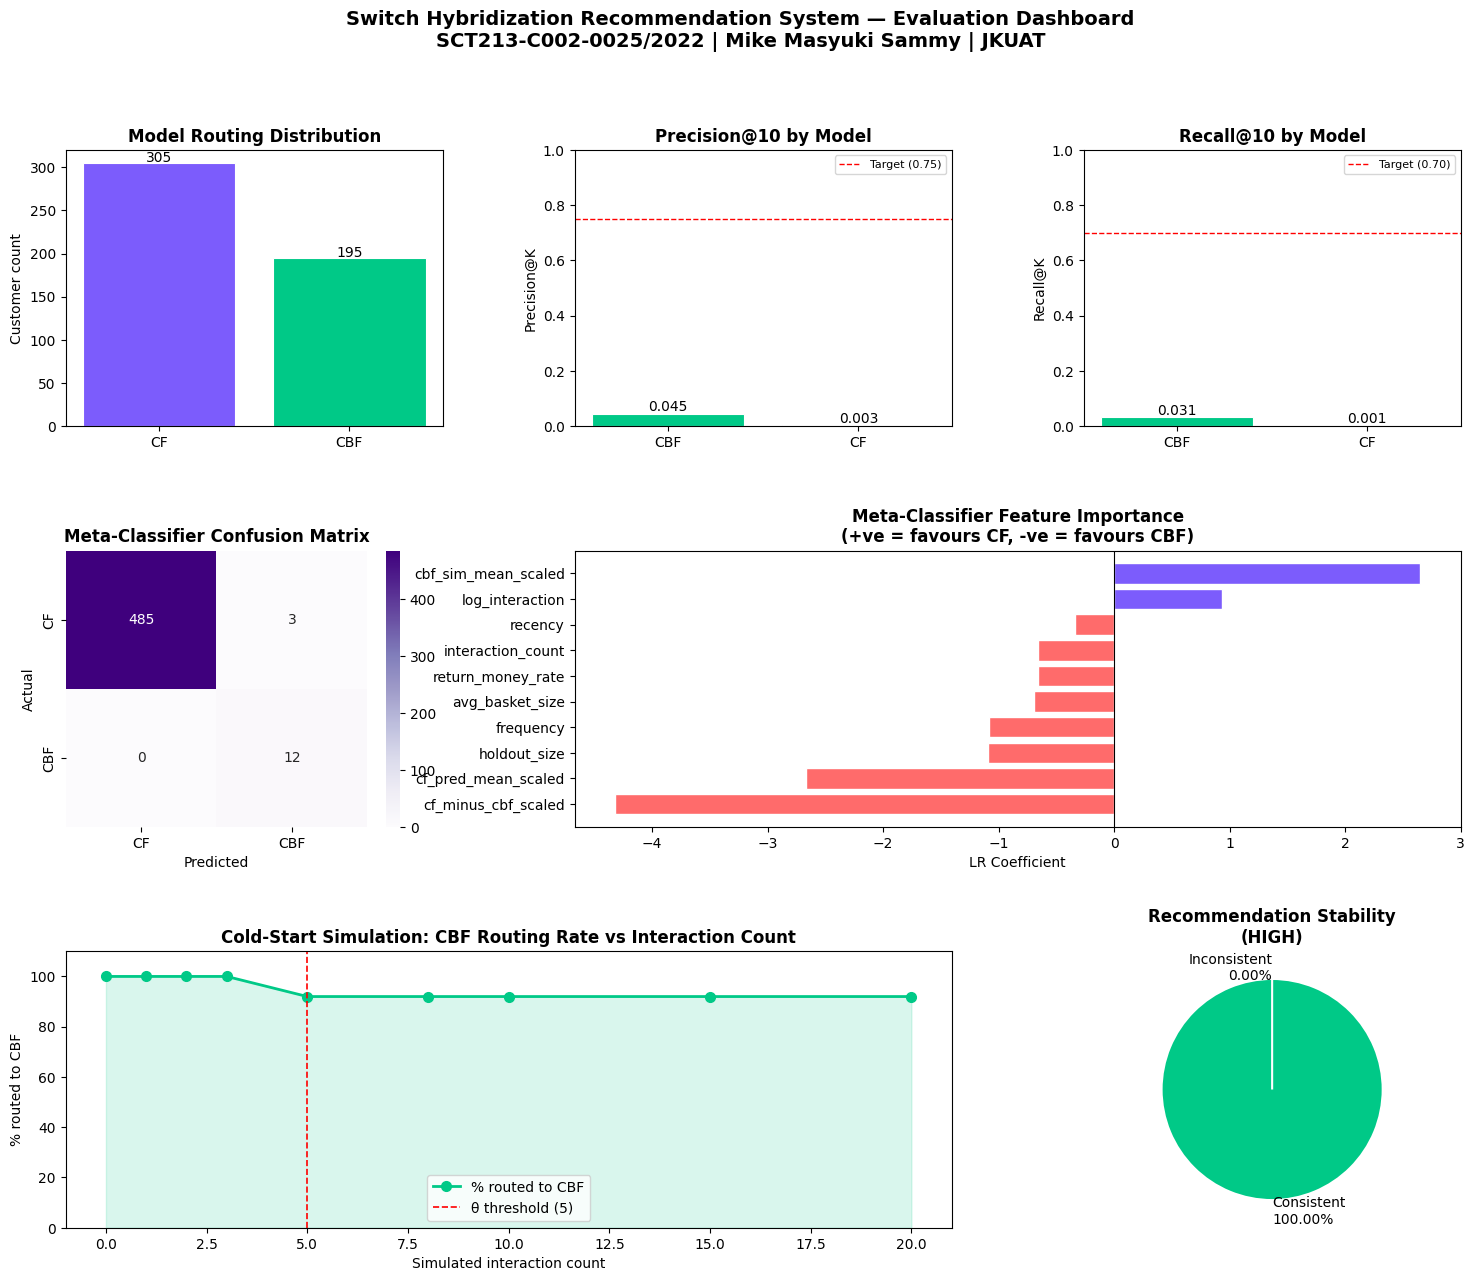

📊 Evaluation dashboard saved as switch_hybrid_evaluation.png


In [ ]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "Switch Hybridization Recommendation System — Evaluation Dashboard\n"
    "SCT213-C002-0025/2022 | Mike Masyuki Sammy | JKUAT",
    fontsize=14, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# --- Plot 1: Model routing distribution ---
ax1 = fig.add_subplot(gs[0, 0])
routing_counts = eval_df['model_used'].value_counts()
colors_map     = {'CF': '#7c5cfc', 'CBF': '#00c987', 'POPULARITY': '#ffd166'}
bar_colors     = [colors_map.get(m, '#888') for m in routing_counts.index]
ax1.bar(routing_counts.index, routing_counts.values, color=bar_colors, edgecolor='white', linewidth=0.8)
ax1.set_title('Model Routing Distribution', fontweight='bold')
ax1.set_ylabel('Customer count')
for i, v in enumerate(routing_counts.values):
    ax1.text(i, v + 1, str(v), ha='center', fontsize=10)

# --- Plot 2: Precision@K by model ---
ax2 = fig.add_subplot(gs[0, 1])
prec_by_model = eval_df.groupby('model_used')['precision_k'].mean()
ax2.bar(prec_by_model.index, prec_by_model.values,
        color=[colors_map.get(m, '#888') for m in prec_by_model.index],
        edgecolor='white', linewidth=0.8)
ax2.axhline(0.75, color='red', linestyle='--', linewidth=1, label='Target (0.75)')
ax2.set_title(f'Precision@{K} by Model', fontweight='bold')
ax2.set_ylabel('Precision@K')
ax2.legend(fontsize=8)
ax2.set_ylim(0, 1)
for i, v in enumerate(prec_by_model.values):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

# --- Plot 3: Recall@K by model ---
ax3 = fig.add_subplot(gs[0, 2])
rec_by_model = eval_df.groupby('model_used')['recall_k'].mean()
ax3.bar(rec_by_model.index, rec_by_model.values,
        color=[colors_map.get(m, '#888') for m in rec_by_model.index],
        edgecolor='white', linewidth=0.8)
ax3.axhline(0.70, color='red', linestyle='--', linewidth=1, label='Target (0.70)')
ax3.set_title(f'Recall@{K} by Model', fontweight='bold')
ax3.set_ylabel('Recall@K')
ax3.legend(fontsize=8)
ax3.set_ylim(0, 1)
for i, v in enumerate(rec_by_model.values):
    ax3.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

# --- Plot 4: Meta-classifier confusion matrix ---
ax4 = fig.add_subplot(gs[1, 0])
cm = confusion_matrix(y_test_sw, y_pred_sw)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax4,
            xticklabels=['CF', 'CBF'], yticklabels=['CF', 'CBF'])
ax4.set_title('Meta-Classifier Confusion Matrix', fontweight='bold')
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')

# --- Plot 5: Feature importance (LR coefficients) ---
ax5 = fig.add_subplot(gs[1, 1:])
coef_plot = coef_df.head(10).sort_values('Coefficient')
bar_c     = ['#7c5cfc' if v >= 0 else '#ff6b6b' for v in coef_plot['Coefficient']]
ax5.barh(coef_plot['Feature'], coef_plot['Coefficient'], color=bar_c, edgecolor='white')
ax5.axvline(0, color='black', linewidth=0.8)
ax5.set_title('Meta-Classifier Feature Importance\n(+ve = favours CF, -ve = favours CBF)', fontweight='bold')
ax5.set_xlabel('LR Coefficient')

# --- Plot 6: Cold-start simulation ---
ax6 = fig.add_subplot(gs[2, 0:2])
ax6.plot(sim_df['simulated_interactions'], sim_df['cbf_pct'],
         marker='o', color='#00c987', linewidth=2, markersize=7, label='% routed to CBF')
ax6.axvline(COLD_START_THRESHOLD, color='red', linestyle='--', linewidth=1.2, label=f'θ threshold ({COLD_START_THRESHOLD})')
ax6.fill_between(sim_df['simulated_interactions'], sim_df['cbf_pct'], alpha=0.15, color='#00c987')
ax6.set_title('Cold-Start Simulation: CBF Routing Rate vs Interaction Count', fontweight='bold')
ax6.set_xlabel('Simulated interaction count')
ax6.set_ylabel('% routed to CBF')
ax6.set_ylim(0, 110)
ax6.legend()

# --- Plot 7: Stability score ---
ax7 = fig.add_subplot(gs[2, 2])
stability_label = 'HIGH' if stability_score > 0.8 else 'MODERATE' if stability_score > 0.5 else 'LOW'
stability_color = '#00c987' if stability_score > 0.8 else '#ffd166' if stability_score > 0.5 else '#ff6b6b'
ax7.pie(
    [stability_score, 1 - stability_score],
    labels=[f'Consistent\n{stability_score:.2%}', f'Inconsistent\n{1-stability_score:.2%}'],
    colors=[stability_color, '#e0e0e0'],
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax7.set_title(f'Recommendation Stability\n({stability_label})', fontweight='bold')

plt.savefig('switch_hybrid_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Evaluation dashboard saved as switch_hybrid_evaluation.png")




## Cell 17 — Run the hybrid router on three representative customers:


In [ ]:
# one cold-start, one mid-range, one power user.

print("\n" + "=" * 60)
print("  LIVE RECOMMENDATION DEMO")
print("=" * 60)

demo_customers = {
    'Cold-Start (new user)': 'Guest',
}

# Pick one mid-range and one high-interaction customer from eval set
sorted_by_interactions = switch_features_df.sort_values('interaction_count')
mid_user   = sorted_by_interactions.iloc[len(sorted_by_interactions) // 2]['CustomerID']
power_user = sorted_by_interactions.iloc[-1]['CustomerID']
demo_customers['Mid-range user']  = mid_user
demo_customers['Power user (CF)'] = power_user

for label, cid in demo_customers.items():
    print(f"\n{'─'*60}")
    print(f"  Customer type : {label}")
    print(f"  CustomerID    : {cid}")
    ic = interaction_df[interaction_df['CustomerID'] == cid].shape[0] if cid != 'Guest' else 0
    print(f"  |Rᵤ|          : {ic} interactions")
    recs, model, reason = get_hybrid_recommendation(cid, top_k=5)
    print(f"  Model used    : {model}")
    print(f"  Reason        : {reason}")
    print(f"\n  Top 5 Recommendations:")
    score_col = 'cf_score' if 'cf_score' in recs.columns else 'cbf_score'
    display_cols = ['StockCode', 'Description', 'AvgPrice', score_col]
    display_cols = [c for c in display_cols if c in recs.columns]
    print(recs[display_cols].head(5).to_string(index=False))

print("\n" + "=" * 60)
print("✅ Switch Hybridization Recommendation System — Complete.")
print("   All evaluation metrics, model weights, and charts produced.")
print("=" * 60)



  LIVE RECOMMENDATION DEMO

────────────────────────────────────────────────────────────
  Customer type : Cold-Start (new user)
  CustomerID    : Guest
  |Rᵤ|          : 0 interactions
🔀 Router → CONTENT-BASED FILTERING  |  Cold-start: |Rᵢ|=0 < θ=5. No CF signal — using content-based filtering.
  Model used    : CBF
  Reason        : Cold-start: |Rᵢ|=0 < θ=5. No CF signal — using content-based filtering.

  Top 5 Recommendations:
StockCode                    Description  AvgPrice  cbf_score
    84854            GIRLY PINK TOOL SET   4.95000   0.049155
   35004P     SET OF 3 PINK FLYING DUCKS   5.45000   0.049155
    21827 EIGHT PIECE CREEPY CRAWLIE SET   1.25000   0.047460
    16259   PIECE OF CAMO STATIONERY SET   0.09625   0.047460
   62097B      BLUE STRIPES SHOULDER BAG   0.83000   0.038833

────────────────────────────────────────────────────────────
  Customer type : Mid-range user
  CustomerID    : 14744
  |Rᵤ|          : 21 interactions
🔀 Router → CONTENT-BASED FILTERING  |  